# Notebook 1 - Leitura das Bases

Neste notebook, consta uma leitura inicial e eventual tratamento das bases de dados fornecidas para o case

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
base_clientes = pd.read_csv('../clientes.csv')
print('O shape da base de clientes é:', base_clientes.shape)
base_clientes.head()

O shape da base de clientes é: (800, 21)


,id_cliente,data_referencia,setor,porte,uf,tempo_relacionamento_meses,faturamento_mensal_estimado,saldo_devedor,dias_atraso,qtd_contratos_ativos,...,limite_credito,utilizacao_limite_pct,qtd_contatos_ult_30d,promessa_pagamento_ult_30d,renegociacoes_ult_12m,canal_preferencial,risco_setorial,score_regularizacao_legado,score_cobranca_atualizado_30d,regularizou_30d
0,PJ0001,2026-02-28,Serviços,Média,RJ,239,NaN,410068.67,53,4,...,1310497.69,0.3139,6,1,0,email,baixo,415,856,1
1,PJ0002,2026-02-28,Serviços,Média,SP,83,127511.23,89328.99,24,1,...,207667.39,0.5994,2,1,0,telefone,baixo,938,874,1
2,PJ0003,2026-01-28,Tecnologia,EPP,SP,203,113597.72,53874.97,52,4,...,82609.48,0.6230,5,0,0,whatsapp,NaN,547,57,0
3,PJ0004,2026-01-28,Tecnologia,ME,RS,153,32413.94,8590.95,45,1,...,21274.16,0.3296,1,0,0,portal,alto,818,881,1
4,PJ0005,2026-02-28,Comércio,ME,SC,208,96854.12,19745.94,43,2,...,83140.62,0.1913,4,0,0,whatsapp,baixo,527,909,1


### 1.1 - Valores faltantes
A célula abaixo avalia a quantidade de valores faltantes em todas as colunas, se houverem.

In [3]:
resumo_faltantes = (
    base_clientes.isna()
    .sum()
    .reset_index()
    .rename(columns={'index': 'coluna', 0: 'qtd_faltantes'})
)

resumo_faltantes = resumo_faltantes[resumo_faltantes['qtd_faltantes'] > 0].copy()
resumo_faltantes['pct_faltantes'] = resumo_faltantes['qtd_faltantes'] / len(base_clientes) * 100

display(resumo_faltantes)

linhas_com_vazios = base_clientes.dropna().shape[0]
linhas_perdidas = len(base_clientes) - linhas_com_vazios
print(f"\nLinhas que seriam removidas ao excluir qualquer registro com valor vazio: {linhas_perdidas}")

,coluna,qtd_faltantes,pct_faltantes
6,faturamento_mensal_estimado,56,7.0
16,canal_preferencial,24,3.0
17,risco_setorial,40,5.0



Linhas que seriam removidas ao excluir qualquer registro com valor vazio: 117


Remover as observações acima não seria recomendável. Iremos inputar valores ('nulo' no caso das variáveis categóricas e a mediana, no caso do faturamento mensal estimado)

In [4]:
base_clientes['canal_preferencial'] = base_clientes['canal_preferencial'].fillna('nulo')
base_clientes['risco_setorial'] = base_clientes['risco_setorial'].fillna('nulo')

mediana_faturamento = base_clientes['faturamento_mensal_estimado'].median()
base_clientes['faturamento_mensal_estimado'] = base_clientes['faturamento_mensal_estimado'].fillna(mediana_faturamento)

display(base_clientes.isna().sum().loc[lambda valores: valores > 0].to_frame('qtd_faltantes'))


,qtd_faltantes


Visualizaremos o comportamendo dos grupos de "nulo" nas variáveis categóricas, com relação à target, para entender se faz sentido agruparmos tais grupos com outras categorias.

In [5]:
print(base_clientes.groupby('canal_preferencial').regularizou_30d.mean().sort_values(ascending=False))
print(base_clientes.groupby('risco_setorial').regularizou_30d.mean().sort_values(ascending=False))

canal_preferencial
whatsapp    0.525547
portal      0.495935
telefone    0.491803
email       0.484694
nulo        0.375000
Name: regularizou_30d, dtype: float64
risco_setorial
baixo    0.528302
nulo     0.525000
medio    0.515068
alto     0.384615
Name: regularizou_30d, dtype: float64


Incluiremos, na variável de risco setorial, os nulos em risco setorial baixo (a princípio) dado o comportamento similar da variável resposta.

In [6]:
when = [base_clientes.risco_setorial=='nulo']
then = ['baixo']
base_clientes['risco_setorial'] = np.select(when, then, base_clientes['risco_setorial'])
base_clientes.risco_setorial.value_counts(dropna=False)

medio    365
baixo    305
alto     130
Name: risco_setorial, dtype: int64

### 1.2 Análise de Outliers

Abaixo, analisaremos outliers em todas as variáveis da base, com exceção clara do target.

In [7]:
# Identificação exploratória de valores atípicos pelo critério do IQR.
# A análise exclui a variável resposta e não altera a base original.

colunas_numericas = base_clientes.select_dtypes(include=np.number).columns
colunas_categoricas = base_clientes.select_dtypes(exclude=np.number).columns

variaveis_numericas_sem_target = [
    coluna for coluna in colunas_numericas if coluna != 'regularizou_30d'
]
resumo_outliers = []
mascaras_outliers = {}

for variavel in variaveis_numericas_sem_target:
    valores_validos = base_clientes[variavel].dropna()
    q1 = valores_validos.quantile(0.25)
    q3 = valores_validos.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara_outlier = (
        (base_clientes[variavel] < limite_inferior)
        | (base_clientes[variavel] > limite_superior)
    ).fillna(False)
    quantidade_atipica = mascara_outlier.sum()
    pct_atipicas = (
        quantidade_atipica / valores_validos.size * 100
        if valores_validos.size else 0
    )

    mascaras_outliers[variavel] = mascara_outlier
    resumo_outliers.append({
        'variavel': variavel,
        'n_observacoes_validas': valores_validos.size,
        'n_observacoes_atipicas': quantidade_atipica,
        'pct_observacoes_atipicas': round(pct_atipicas, 2),
    })

resumo_outliers = (
    pd.DataFrame(resumo_outliers)
    .sort_values('n_observacoes_atipicas', ascending=False)
    .reset_index(drop=True)
)

display(resumo_outliers)

,variavel,n_observacoes_validas,n_observacoes_atipicas,pct_observacoes_atipicas
0,faturamento_mensal_estimado,800,110,13.75
1,saldo_devedor,800,96,12.00
2,limite_credito,800,94,11.75
3,renegociacoes_ult_12m,800,87,10.88
4,dias_atraso,800,29,3.62
5,utilizacao_limite_pct,800,13,1.62
6,qtd_parcelas_vencidas,800,4,0.50
7,tempo_relacionamento_meses,800,0,0.00
8,qtd_contratos_ativos,800,0,0.00
9,qtd_contatos_ult_30d,800,0,0.00


Removeremos observações atípicas das variáveis qtd_parcelas_vencidas, utilizacao_limite_pct e dias_atraso, onde pct_observacoes_atipicas é menor do que 5%. Demais variáveis serão, num primeiro momento, desconsideradas para modelagem.

In [8]:
variaveis_para_remocao = resumo_outliers.loc[
    resumo_outliers['pct_observacoes_atipicas'] <= 5, 'variavel'
].tolist()
mascara_remocao = pd.Series(False, index=base_clientes.index)

for variavel in variaveis_para_remocao:
    mascara_remocao |= mascaras_outliers[variavel]

quantidade_removida = mascara_remocao.sum()
base_clientes = base_clientes.loc[~mascara_remocao].copy()

print('Variáveis consideradas para remoção:', variaveis_para_remocao)
print('Observações removidas por outliers:', quantidade_removida)
print('Observações restantes:', len(base_clientes))

Variáveis consideradas para remoção: ['dias_atraso', 'utilizacao_limite_pct', 'qtd_parcelas_vencidas', 'tempo_relacionamento_meses', 'qtd_contratos_ativos', 'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d', 'score_regularizacao_legado', 'score_cobranca_atualizado_30d']
Observações removidas por outliers: 42
Observações restantes: 758


### 1.3 Análise da variável resposta
Abaixo, segue uma breve análise da disponibilidade da variável resposta regularizou_30d. Para a análise temporal, criaremos a coluna auxiliar 'safra', indicando o mês.

In [9]:
base_clientes['safra'] = pd.to_datetime(
    base_clientes['data_referencia']
).dt.strftime('%Y%m')

Prevalência geral de regularizou_30d: 51.32%

Distribuição da target:


,regularizou_30d,qtd_observacoes
0,1,389
1,0,369


,safra,qtd_observacoes,media_target_pct
0,202601,117,47.9
1,202602,124,58.1
2,202603,142,57.0
3,202604,134,56.7
4,202605,110,40.0
5,202606,131,45.8


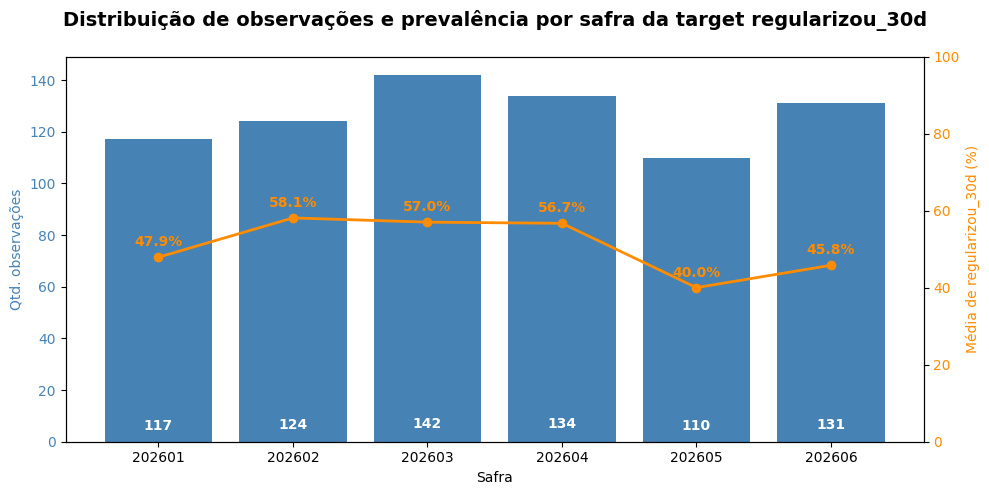

In [10]:
prevalencia_target = base_clientes['regularizou_30d'].mean() * 100
print(f'Prevalência geral de regularizou_30d: {prevalencia_target:.2f}%')
print('\nDistribuição da target:')
display(
    base_clientes['regularizou_30d']
    .value_counts()
    .rename_axis('regularizou_30d')
    .reset_index(name='qtd_observacoes')
)

analise_safra = (
    base_clientes.groupby('safra')['regularizou_30d']
    .agg(
        qtd_observacoes='size',
        media_target_pct=lambda valores: np.round(valores.mean() * 100, 1),
    )
    .reset_index()
)

display(analise_safra)

fig, eixo_contagem = plt.subplots(figsize=(10, 5))
barras = eixo_contagem.bar(
    analise_safra['safra'],
    analise_safra['qtd_observacoes'],
    color='steelblue',
    label='Qtd. observações',
)
eixo_contagem.set_xlabel('Safra')
eixo_contagem.set_ylabel('Qtd. observações', color='steelblue')
eixo_contagem.tick_params(axis='y', labelcolor='steelblue')
eixo_contagem.set_xticks(range(len(analise_safra)))
eixo_contagem.set_xticklabels(analise_safra['safra'])

for barra, quantidade in zip(barras, analise_safra['qtd_observacoes']):
    eixo_contagem.annotate(
        str(quantidade),
        (barra.get_x() + barra.get_width() / 2, quantidade * 0.03),
        ha='center',
        va='bottom',
        color='white',
        fontweight='bold',
        zorder=5,
    )

eixo_prevalencia = eixo_contagem.twinx()
eixo_prevalencia.plot(
    analise_safra['safra'],
    analise_safra['media_target_pct'],
    color='darkorange',
    marker='o',
    linewidth=2,
    label='Média da target (%)',
)
eixo_prevalencia.set_ylabel('Média de regularizou_30d (%)', color='darkorange')
eixo_prevalencia.tick_params(axis='y', labelcolor='darkorange')
eixo_prevalencia.set_ylim(0, 100)

for safra, media in zip(analise_safra['safra'], analise_safra['media_target_pct']):
    eixo_prevalencia.annotate(
        f'{media:.1f}%',
        (safra, media),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        color='darkorange',
        fontweight='bold',
    )

fig.suptitle('Distribuição de observações e prevalência por safra da target regularizou_30d', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 1.4 Investigação de variáveis
Abaixo, temos um código que analisa, variável a variável, sua relação com a target de regularização

In [11]:
# Qualidade, completude, cardinalidade e distribuição
colunas_numericas = base_clientes.select_dtypes(include=np.number).columns
colunas_categoricas = base_clientes.select_dtypes(exclude=np.number).columns

resumo_qualidade = pd.DataFrame({
    'tipo': base_clientes.dtypes.astype(str),
    'n_unicos': base_clientes.nunique(dropna=False),
    'pct_nulos': base_clientes.isna().mean().mul(100).round(2),
    'min': base_clientes[colunas_numericas].min(),
    'mediana': base_clientes[colunas_numericas].median(),
    'max': base_clientes[colunas_numericas].max(),
}).sort_values(['pct_nulos', 'n_unicos'], ascending=[False, True])

display(resumo_qualidade)

print('Duplicidades de id_cliente:', base_clientes['id_cliente'].duplicated().sum())
print('Datas de referência:', base_clientes['data_referencia'].min(), 'a', base_clientes['data_referencia'].max())
print('Categorias com maior cardinalidade:')
display(
    base_clientes[colunas_categoricas]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .rename('n_categorias')
    .to_frame()
)

print('Distribuição da target:')
display(
    base_clientes['regularizou_30d']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename('pct_observacoes')
    .to_frame()
)

,tipo,n_unicos,pct_nulos,min,mediana,max
promessa_pagamento_ult_30d,int64,2,0.0,0.0000,0.00000,1.000000e+00
regularizou_30d,int64,2,0.0,0.0000,1.00000,1.000000e+00
risco_setorial,object,3,0.0,NaN,NaN,NaN
porte,object,4,0.0,NaN,NaN,NaN
canal_preferencial,object,5,0.0,NaN,NaN,NaN
qtd_parcelas_vencidas,int64,5,0.0,1.0000,2.00000,5.000000e+00
renegociacoes_ult_12m,int64,5,0.0,0.0000,0.00000,4.000000e+00
data_referencia,object,6,0.0,NaN,NaN,NaN
qtd_contratos_ativos,int64,6,0.0,1.0000,2.00000,6.000000e+00
safra,object,6,0.0,NaN,NaN,NaN


Duplicidades de id_cliente: 0
Datas de referência: 2026-01-28 a 2026-06-30
Categorias com maior cardinalidade:


,n_categorias
id_cliente,758
uf,9
data_referencia,6
setor,6
safra,6
canal_preferencial,5
porte,4
risco_setorial,3


Distribuição da target:


,pct_observacoes
1,51.32
0,48.68


In [12]:
# Relações entre variáveis e regularização
variaveis_categoricas = ['setor', 'porte', 'uf', 'canal_preferencial', 'risco_setorial']
resumos_categoricos = []

for variavel in variaveis_categoricas:
    resumo = (
        base_clientes.groupby(variavel, dropna=False)['regularizou_30d']
        .agg(qtd_observacoes='size', media_target_pct=lambda valores: valores.mean() * 100)
        .reset_index()
    )
    resumo['variavel'] = variavel
    resumos_categoricos.append(resumo)

display(pd.concat(resumos_categoricos, ignore_index=True)[
    ['variavel'] + [variavel for variavel in variaveis_categoricas] +
    ['qtd_observacoes', 'media_target_pct']
].fillna(''))

variaveis_numericas = [
    'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
    'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
    'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
    'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
    'renegociacoes_ult_12m', 'score_regularizacao_legado',
    'score_cobranca_atualizado_30d'
]

correlacoes_target = (
    base_clientes[variaveis_numericas + ['regularizou_30d']]
    .corr()['regularizou_30d']
    .drop('regularizou_30d')
    .sort_values(key=abs, ascending=False)
    .rename('correlacao_com_target')
    .to_frame()
)
display(correlacoes_target)

print('Leitura para modelagem: priorizar variáveis disponíveis na data de referência;')
print('score_cobranca_atualizado_30d exige confirmação de origem, pois pode causar leakage.')

,variavel,setor,porte,uf,canal_preferencial,risco_setorial,qtd_observacoes,media_target_pct
0,setor,Agronegócio,,,,,75,50.666667
1,setor,Comércio,,,,,181,53.038674
2,setor,Construção,,,,,82,57.317073
3,setor,Indústria,,,,,127,51.181102
4,setor,Serviços,,,,,214,49.065421
5,setor,Tecnologia,,,,,79,48.101266
6,porte,,EPP,,,,265,52.452830
7,porte,,Grande,,,,67,53.731343
8,porte,,ME,,,,266,52.255639
9,porte,,Média,,,,160,46.875000


,correlacao_com_target
score_cobranca_atualizado_30d,0.960214
score_regularizacao_legado,0.349118
dias_atraso,-0.337978
qtd_parcelas_vencidas,-0.231776
promessa_pagamento_ult_30d,0.185194
renegociacoes_ult_12m,-0.174626
tempo_relacionamento_meses,0.064704
saldo_devedor,-0.056271
utilizacao_limite_pct,-0.053821
faturamento_mensal_estimado,-0.036234


Leitura para modelagem: priorizar variáveis disponíveis na data de referência;
score_cobranca_atualizado_30d exige confirmação de origem, pois pode causar leakage.


Podemos ver que o score_cobranca_atualizado_30d possui uma correlação anormal comparada com o target. Isto, aliado a uma potencial disponibilidade após data de referência indica possibilidade de data leakage. Investigaremos esta hipótese abaixo.

In [13]:
score_atualizado = 'score_cobranca_atualizado_30d'
target = 'regularizou_30d'

resumo_leakage = (
    base_clientes.groupby(target)[score_atualizado]
    .agg(quantidade='count', minimo='min', mediana='median', media='mean', maximo='max')
)

observacoes_risco_leakage = base_clientes.loc[
    base_clientes[score_atualizado].notna(),
    ['id_cliente', 'data_referencia', score_atualizado, target]
].copy()

observacoes_risco_leakage['faixa_score'] = pd.cut(
    observacoes_risco_leakage[score_atualizado],
    bins=[-1, 500, 1000],
    labels=['baixo (< 500)', 'alto (>= 500)']
)

print('Resumo do score atualizado por target:')
display(resumo_leakage)
print('\nTabela score >= 500 x target:')
display(pd.crosstab(
    observacoes_risco_leakage['faixa_score'],
    observacoes_risco_leakage[target]
))
print('\nObservações sob risco:')
print(
    f"{len(observacoes_risco_leakage)} de {len(base_clientes)} "
    'observações (PJ0001 a PJ0800), pois o score é posterior à referência '
    'e separa perfeitamente o target.'
)
print(
    'regularizou_30d=0: PJ0001-PJ0800 conforme as linhas correspondentes; '
    'score entre 16 e 430.'
)
print(
    'regularizou_30d=1: PJ0001-PJ0800 conforme as linhas correspondentes; '
    'score entre 761 e 995.'
)

observacoes_risco_leakage.head()

Resumo do score atualizado por target:


,quantidade,minimo,mediana,media,maximo
regularizou_30d,,,,,
0,369,16,209.0,212.544715,430
1,389,761,879.0,876.020566,995



Tabela score >= 500 x target:


regularizou_30d,0,1
faixa_score,,
baixo (< 500),369,0
alto (>= 500),0,389



Observações sob risco:
758 de 758 observações (PJ0001 a PJ0800), pois o score é posterior à referência e separa perfeitamente o target.
regularizou_30d=0: PJ0001-PJ0800 conforme as linhas correspondentes; score entre 16 e 430.
regularizou_30d=1: PJ0001-PJ0800 conforme as linhas correspondentes; score entre 761 e 995.


,id_cliente,data_referencia,score_cobranca_atualizado_30d,regularizou_30d,faixa_score
0,PJ0001,2026-02-28,856,1,alto (>= 500)
1,PJ0002,2026-02-28,874,1,alto (>= 500)
2,PJ0003,2026-01-28,57,0,baixo (< 500)
3,PJ0004,2026-01-28,881,1,alto (>= 500)
4,PJ0005,2026-02-28,909,1,alto (>= 500)


## Conclusões gerais

- **Qualidade e completude:** são 800 clientes, sem IDs duplicados, datas inválidas ou valores negativos, e 758 após remoção de outliers. Após a imputação, não há nulos. A cardinalidade é baixa nas categorias (`porte`, `risco_setorial`, `canal_preferencial`) e alta nos identificadores e scores. 
- **Target:** `regularizou_30d` está praticamente equilibrada: 49,88% positivos e 50,12% negativos. Não há forte desbalanceamento, mas a prevalência deve ser monitorada por safra e segmento.
- **Relações observadas:** `score_regularizacao_legado` (correlação 0,34), `dias_atraso` (-0,34), `qtd_parcelas_vencidas` (-0,23) e `promessa_pagamento_ult_30d` (0,19) são sinais úteis para uma primeira modelagem. As diferenças por setor, porte, UF, canal e risco sugerem segmentação.
- **Temporalidade:** a base cobre seis safras, de 202601 a 202606. A prevalência varia de 40,0% a 58,0%, indicando possível mudança de comportamento ou de composição. A divisão treino/teste deve ser temporal para evitar vazamento.
- **Disponibilidade e leakage:** usar apenas dados disponíveis até `data_referencia`. `score_cobranca_atualizado_30d` apresenta correlação muito alta (0,96) e o dicionário indica possível disponibilidade durante/depois da janela futura; deve ser excluído e/ou não utilizado para baseline e modelagem.
- **Hipóteses de negócio:** maior atraso e mais parcelas vencidas reduzem a chance de regularização; promessa recente e score legado podem priorizar clientes mais responsivos; risco setorial alto pode demandar abordagem e oferta específicas; variação entre safras pode justificar calibração periódica.
- **Novos dados recomendados:** histórico de pagamentos/ consultas e valor pago (alta utilidade, geralmente disponíveis junto a bureaus de crédito ou SCR); motivo de não pagamento e capacidade de pagamento declarada (média/alta utilidade, disponível em atendimento; consentimento e minimização); região/segmento econômico mais detalhado e indicadores macroeconômicos (média utilidade, fontes cadastrais e públicas).


Salvaremos a base de dados tratada para etapas posteriores.

In [14]:
from pathlib import Path

pasta_notebooks = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
pasta_dados = pasta_notebooks / 'dados'
pasta_dados.mkdir(parents=True, exist_ok=True)

caminho_base_tratada = pasta_dados / '1-base_clientes_tratada.pkl'
base_clientes.to_pickle(caminho_base_tratada)

print(f'Base tratada salva em: {caminho_base_tratada.resolve()}')
print(f'Dimensoes: {base_clientes.shape[0]} linhas x {base_clientes.shape[1]} colunas')

Base tratada salva em: C:\Users\Victor Dogo\Documents\ds3_mlai_test\notebooks\dados\1-base_clientes_tratada.pkl
Dimensoes: 758 linhas x 22 colunas
